In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df = pd.read_csv("C:\\Users\\north\\Downloads\\Summer Project\\Dataset (1).csv")

In [55]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [56]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [57]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [58]:
df.isnull().sum()


Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [59]:
df.nunique()

Customer ID               3900
Age                         53
Gender                       2
Item Purchased              25
Category                     4
Purchase Amount (USD)       81
Location                    50
Size                         4
Color                       25
Season                       4
Review Rating               26
Subscription Status          2
Shipping Type                6
Discount Applied             2
Promo Code Used              2
Previous Purchases          50
Payment Method               6
Frequency of Purchases       7
dtype: int64

In [60]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)

In [61]:
df.isnull().sum()

customer_id                0
age                        0
gender                     0
item_purchased             0
category                   0
purchase_amount_usd        0
location                   0
size                       0
color                      0
season                     0
review_rating             37
subscription_status        0
shipping_type              0
discount_applied           0
promo_code_used            0
previous_purchases         0
payment_method             0
frequency_of_purchases     0
dtype: int64

In [62]:
df['rating_missing_flag'] = df['review_rating'].isnull().astype(int)

In [63]:
# Handling missing values in review rating column
df['review_rating'] = df['review_rating'].fillna(
    df['review_rating'].median()
)

In [64]:
# remove duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [65]:
# standarised text value
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

In [66]:
# CONVERT YES/NO TO 1/0
binary_cols = [
    'subscription_status',
    'discount_applied',
    'promo_code_used'
]

for col in binary_cols:
    df[col] = df[col].map({'yes':1, 'no':0})

In [68]:
# CREATE AGE GROUPS
bins = [18,25,35,50,100]
labels = [
    'young_adult',
    'emerging_professional',
    'core_buyers',
    'mature_buyers'
]

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

In [69]:
# Loyalty Metrics 
# Purchase Frequency Score
freq_map = {
    'weekly': 52,
    'fortnightly': 26,
    'monthly': 12,
    'quarterly': 4,
    'annually': 1,
    'every 3 months': 4,
    'bi-weekly': 26
}

df['purchase_frequency_score'] = (
    df['frequency_of_purchases']
    .map(freq_map)
)

In [70]:
# Loyalty Metrics
# Loyalty Score
df['promo_dependency_score'] = (
    (
        0.4 * df['discount_applied']
        +
        0.3 * df['promo_code_used']
        +
        0.3 * (1 - df['subscription_status'])
    )
)

In [71]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_cols = [
    'previous_purchases',
    'purchase_frequency_score',
    'purchase_amount_usd'
]

scaled_data = scaler.fit_transform(df[scaled_cols])

df['scaled_previous_purchases'] = scaled_data[:,0]
df['scaled_purchase_frequency'] = scaled_data[:,1]
df['scaled_purchase_amount'] = scaled_data[:,2]

df['loyalty_score'] = (
    0.4 * df['scaled_previous_purchases'] +
    0.3 * df['scaled_purchase_frequency'] +
    0.2 * df['subscription_status'] +
    0.1 * (1 - df['promo_dependency_score'])
)

In [72]:
# Loyalty Metric
# Loyalty Tier 
df['loyalty_tier'] = pd.qcut(
    df['loyalty_score'],
    q=4,
    labels=['low_loyalty','moderate_loyalty','high_loyalty','vip_loyalty']
)

In [73]:
# CUSTOMER VALUE METRICS
# Estimated Customer Lifetime Value (CLV)
df['estimated_clv'] = (
    df['purchase_amount_usd'] *
    df['purchase_frequency_score'] *
    (df['previous_purchases'] + 1)
)

# Customer Value Score 
df['customer_value_score'] = (
    0.5 * df['purchase_amount_usd'] +
    0.3 * df['previous_purchases'] +
    0.2 * df['purchase_frequency_score']
)

# Value Tier
df['value_tier'] = pd.qcut(
    df['estimated_clv'],
    q=4,
    labels=['bronze','silver','gold','platinum']
)

In [74]:
# BEHAVIORAL METRICS
# Purchase Intensity
df['purchase_intensity'] = (
    df['purchase_frequency_score'] *
    df['previous_purchases']
)

# Premium Customer Flag
df['premium_customer_flag'] = np.where(
    (
        (df['subscription_status'] == 1) &
        (df['purchase_amount_usd'] > df['purchase_amount_usd'].median())
    ),
    1,
    0
)

# Organic Demand Score
df['organic_demand_score'] = (
    df['purchase_frequency_score'] *
    (1 - df['promo_dependency_score'])
)

In [86]:
# PROMO DEPENDENCY METRICS

# Promo Dependency Segment
conditions = [
    (df['promo_dependency_score'] < 0.3),
    (df['promo_dependency_score'] >= 0.3) &
    (df['promo_dependency_score'] < 0.7),
    (df['promo_dependency_score'] >= 0.7)
]

choices = [
    'low_dependency',
    'moderate_dependency',
    'high_dependency'
]

df['promo_segment'] = np.select(
    conditions,
    choices
)

#Margin Friendly Score
df['margin_friendly_score'] = (
    df['estimated_clv'] *
    (1 - df['promo_dependency_score'])
)

In [76]:
# SATISFACTION METRICS
# Satisfaction Flag
df['satisfaction_flag'] = np.where(
    df['review_rating'] >= 4,
    1,
    0
)

# Dissatisfaction Risk
df['dissatisfaction_risk'] = np.where(
    df['review_rating'] <= 2,
    1,
    0
)

# Customer Health Score
df['customer_health_score'] = (
    0.3 * df['loyalty_score'] +
    0.3 * df['satisfaction_flag'] +
    0.2 * (1 - df['promo_dependency_score']) +
    0.2 * df['customer_value_score']
)

In [77]:
# CUSTOMER RETENTION METRICS
# Retention Potential Score
df['retention_potential_score'] = (
    0.4 * df['loyalty_score'] +
    0.3 * df['satisfaction_flag'] +
    0.2 * (1 - df['promo_dependency_score']) +
    0.1 * df['subscription_status']
)

# Churn Risk Proxy
df['churn_risk_score'] = (
    (1 - df['loyalty_score']) +
    df['promo_dependency_score'] +
    (1 - df['satisfaction_flag'])
)

# Retention Category
conditions = [
    (df['retention_potential_score'] >= 0.75),
    (df['retention_potential_score'] >= 0.5),
    (df['retention_potential_score'] < 0.5)
]

choices = [
    'high_retention',
    'moderate_retention',
    'low_retention'
]

df['retention_segment'] = np.select(
    conditions,
    choices
)

In [78]:
# customer segmnetation 

conditions = [

    # VIP Loyalists
    (
        (df['loyalty_score'] >= 0.7) &
        (df['promo_dependency_score'] <= 0.3)
    ),

    # Promo Hunters
    (
        (df['promo_dependency_score'] >= 0.7) &
        (df['loyalty_score'] < 0.5)
    ),

    # High Potential
    (
        (df['customer_health_score'] >= 0.55) &
        (df['loyalty_score'] >= 0.5) &
        (df['promo_dependency_score'] < 0.7)
    ),

    # At Risk
    (
        (df['retention_potential_score'] < 0.4)
    )
]

choices = [
    'vip_loyalists',
    'promo_hunters',
    'high_potential',
    'at_risk'
]

df['customer_segment'] = np.select(
    conditions,
    choices,
    default='casual_buyers'
)

In [79]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,...,organic_demand_score,promo_segment,margin_friendly_score,satisfaction_flag,dissatisfaction_risk,customer_health_score,retention_potential_score,churn_risk_score,retention_segment,customer_segment
0,1,55,male,blouse,clothing,53,kentucky,l,gray,winter,...,7.8,high_dependency,6201.0,0,0,7.384954,0.353273,2.216819,low_retention,promo_hunters
1,2,19,male,sweater,clothing,64,maine,l,maroon,winter,...,7.8,high_dependency,1497.6,0,0,7.735567,0.314089,2.314778,low_retention,promo_hunters
2,3,50,male,jeans,clothing,73,massachusetts,s,maroon,spring,...,15.6,high_dependency,27331.2,0,0,11.032878,0.443837,1.990408,low_retention,casual_buyers
3,4,21,male,sandals,footwear,90,rhode island,m,maroon,spring,...,15.6,high_dependency,70200.0,0,0,14.356551,0.528735,1.778163,moderate_retention,casual_buyers
4,5,45,male,blouse,clothing,49,oregon,m,turquoise,spring,...,0.3,high_dependency,470.4,0,0,7.002469,0.349959,2.225102,low_retention,promo_hunters


In [80]:
df.to_csv(
    "cleaned_feature_engineered_dataset.csv",
    index=False
)

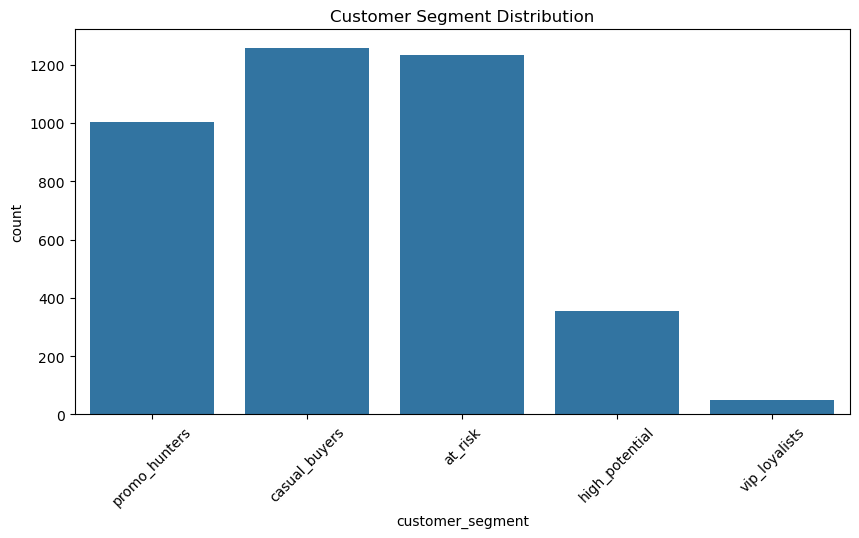

In [81]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='customer_segment',
    data=df
)

plt.title("Customer Segment Distribution")
plt.xticks(rotation=45)
plt.show()

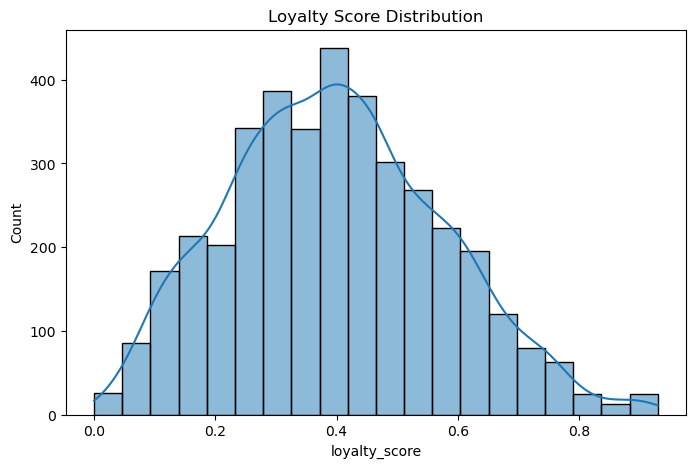

In [82]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['loyalty_score'],
    bins=20,
    kde=True
)

plt.title("Loyalty Score Distribution")
plt.show()

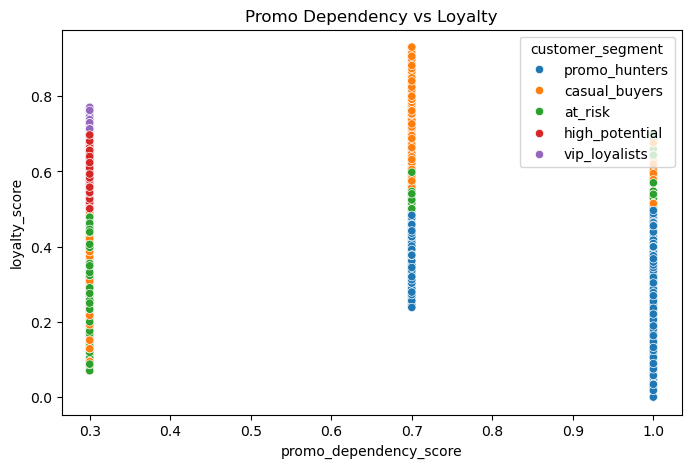

In [83]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='promo_dependency_score',
    y='loyalty_score',
    hue='customer_segment',
    data=df
)

plt.title("Promo Dependency vs Loyalty")
plt.show()

In [84]:
df.to_csv(
    "cleaned_feature_engineered_dataset.csv",
    index=False
)

In [85]:
df.to_excel(
    "cleaned_feature_engineered_dataset.xlsx",
    index=False
)